In [14]:
# JUPYTER CELL: GEV fit + plots from block_maxima CSVs
# - Loads CSVs (file, dir, or glob; directories are searched recursively)
# - Expects columns: 'metric' and 'block_max_value'
# - Fits SciPy GEV per metric, runs KS test, saves JSON + PNGs, and shows plots inline

import os, glob, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genextreme, kstest
from typing import Optional

def _collect_csv_paths(input_path: str):
    """Accept a file path, directory, or glob; return a list of CSV paths. Recurses directories."""
    if os.path.isfile(input_path) and input_path.endswith(".csv"):
        return [input_path]
    if os.path.isdir(input_path):
        # recursive search for any CSV under the directory
        return sorted(glob.glob(os.path.join(input_path, "**", "*.csv"), recursive=True))
    # glob pattern (supports ** if recursive=True)
    return sorted(glob.glob(input_path, recursive=True))

def load_block_maxima(input_path: str) -> pd.DataFrame:
    """Load CSVs that contain 'metric' and 'block_max_value' columns and concatenate."""
    paths = _collect_csv_paths(input_path)
    if not paths:
        raise FileNotFoundError(f"No CSV files found for: {input_path}")
    frames = []
    for p in paths:
        try:
            df = pd.read_csv(p)
        except Exception as e:
            print(f"[WARN] Skipping unreadable CSV {p}: {e}")
            continue
        if {"metric", "block_max_value"}.issubset(df.columns):
            frames.append(df[["metric", "block_max_value"]].copy())
        # silently ignore unrelated CSVs (e.g., merge_metrics.csv)
    if not frames:
        raise ValueError("No CSVs contained the required columns: 'metric', 'block_max_value'.")
    out = pd.concat(frames, ignore_index=True)
    out["block_max_value"] = pd.to_numeric(out["block_max_value"], errors="coerce")
    out = out.dropna(subset=["block_max_value"])
    return out

def fit_gev(values: np.ndarray):
    """Fit SciPy GEV and run KS test; return dict of params + stats."""
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size < 5:
        raise ValueError("Not enough data to fit GEV (need >= 5).")
    # SciPy parameterization: returns (c, loc, scale), classical xi = -c
    c, loc, scale = genextreme.fit(values)
    D, p = kstest(values, 'genextreme', args=(c, loc, scale))
    return {
        "n": int(values.size),
        "shape_c": float(c),
        "xi": float(-c),            # classical xi
        "location_mu": float(loc),
        "scale_beta": float(scale),
        "ks_D": float(D),
        "ks_pvalue": float(p),
    }

def return_level(c: float, loc: float, scale: float, T: np.ndarray) -> np.ndarray:
    """Return level curve for return period T (blocks). Handles the Gumbel limit when c≈0."""
    T = np.asarray(T, dtype=float)
    p = 1.0 - 1.0 / T
    eps = 1e-9
    if abs(c) < 1e-6:
        # Gumbel limit
        q = loc - scale * np.log(-np.log(np.clip(p, eps, 1 - eps)))
    else:
        q = loc + (scale / c) * ((-np.log(np.clip(p, eps, 1 - eps))) ** (-c) - 1.0)
    return q

def plot_hist_with_pdf(values, c, loc, scale, title=None, save_path=None):
    xs = np.linspace(np.nanmin(values), np.nanpercentile(values, 99.5), 400)
    pdf = genextreme.pdf(xs, c, loc=loc, scale=scale)
    plt.figure(figsize=(8, 5))
    plt.hist(values, bins="auto", density=True, alpha=0.6, edgecolor="black")
    plt.plot(xs, pdf, linewidth=2)
    if title: plt.title(title)
    plt.xlabel("Block maxima"); plt.ylabel("Density"); plt.tight_layout()
    if save_path: plt.savefig(save_path)
    plt.show()
    plt.close()

def plot_qq(values, c, loc, scale, title=None, save_path=None):
    n = len(values)
    vs = np.sort(values)
    probs = (np.arange(1, n + 1) - 0.5) / n
    theo = genextreme.ppf(probs, c, loc=loc, scale=scale)
    plt.figure(figsize=(5, 5))
    plt.scatter(theo, vs, s=12)
    mn = min(vs.min(), theo.min()); mx = max(vs.max(), theo.max())
    plt.plot([mn, mx], [mn, mx])
    if title: plt.title(title)
    plt.xlabel("Theoretical quantiles"); plt.ylabel("Empirical quantiles"); plt.tight_layout()
    if save_path: plt.savefig(save_path)
    plt.show()
    plt.close()

def plot_return_level(c, loc, scale, title=None, save_path=None):
    Ts = np.logspace(np.log10(1.5), np.log10(200), 200)
    rl = return_level(c, loc, scale, Ts)
    plt.figure(figsize=(8, 5))
    plt.plot(Ts, rl, linewidth=2)
    plt.xscale("log")
    if title: plt.title(title)
    plt.xlabel("Return period T (blocks)"); plt.ylabel("Return level"); plt.tight_layout()
    if save_path: plt.savefig(save_path)
    plt.show()
    plt.close()

def fit_and_plot_from_csvs(input_path: str, outdir: str, metric: Optional[str] = None, min_blocks: int = 10):
    """
    Load block maxima from CSVs, fit GEV per metric (or for a chosen one),
    show plots inline, and save JSON + PNGs to outdir.
    """
    os.makedirs(outdir, exist_ok=True)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        df = load_block_maxima(input_path)

    available = sorted(df["metric"].dropna().unique().tolist())
    print(f"[INFO] Metrics present: {available}")

    # Decide which metrics to fit
    if metric:
        if metric not in available:
            print(f"[WARN] Requested metric '{metric}' not found. Falling back to ALL metrics present.")
            metrics = available
        else:
            metrics = [metric]
    else:
        metrics = available

    if not metrics:
        print("[WARN] No metrics to fit. Nothing to do.")
        return pd.DataFrame()

    results = []
    for m in metrics:
        series = df.loc[df["metric"] == m, "block_max_value"].dropna().astype(float).values
        series = series[np.isfinite(series)]
        if series.size < min_blocks:
            print(f"[WARN] Skipping metric '{m}' (only {series.size} blocks; need >= {min_blocks})")
            continue

        fit = fit_gev(series)
        c, loc, scale = fit["shape_c"], fit["location_mu"], fit["scale_beta"]
        print(f"[INFO] {m}: n={fit['n']}  c={c:.6f}  xi={fit['xi']:.6f}  mu={loc:.6f}  beta={scale:.6f}  KS p={fit['ks_pvalue']:.4f}")

        # Save JSON
        out_json = os.path.join(outdir, f"gev_{m}_fit.json")
        with open(out_json, "w") as f:
            json.dump({"metric": m, **fit}, f, indent=2)

        # Plots (inline + saved)
        plot_hist_with_pdf(series, c, loc, scale,
                           title=f"{m} — Histogram + GEV PDF",
                           save_path=os.path.join(outdir, f"gev_{m}_hist_pdf.png"))
        plot_qq(series, c, loc, scale,
                title=f"{m} — QQ plot",
                save_path=os.path.join(outdir, f"gev_{m}_qq.png"))
        plot_return_level(c, loc, scale,
                          title=f"{m} — Return level",
                          save_path=os.path.join(outdir, f"gev_{m}_return_level.png"))

        results.append({"metric": m, **fit})

    if not results:
        print("[WARN] No fits produced (too few blocks for all metrics).")
        return pd.DataFrame()

    return pd.DataFrame(results)

# ---------- EXAMPLE USAGE (edit these paths, then run this cell) ----------
# INPUT CAN BE:
#   - a directory (searched recursively), e.g. "/path/to/metrics_dir"
#   - a specific file, e.g. "/path/to/metrics_dir/block_maxima.csv"
#   - a glob, e.g. "/path/to/metrics_dir/**/*.csv"
input_path = "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/tmp/results/20250825_092229"  # <-- change me
outdir = "/tmp/gev_results"          # <-- change me
only_metric = "consumer_producer"    # or "application_consumer", or set to None to fit all found
min_blocks_needed = 10

fit_df = fit_and_plot_from_csvs(input_path, outdir, metric=only_metric, min_blocks=min_blocks_needed)
display(fit_df)


[INFO] Metrics present: ['application_consumer']
[WARN] Requested metric 'consumer_producer' not found. Falling back to ALL metrics present.
[INFO] application_consumer: n=51  c=1.077275  xi=-1.077275  mu=0.099987  beta=0.000014  KS p=0.2807


/var/folders/2z/bnjkw3qd38b7gqpbhfdmfhpc0000gn/T/ipykernel_55773/2006855215.py:85: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()
/var/folders/2z/bnjkw3qd38b7gqpbhfdmfhpc0000gn/T/ipykernel_55773/2006855215.py:100: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()
/var/folders/2z/bnjkw3qd38b7gqpbhfdmfhpc0000gn/T/ipykernel_55773/2006855215.py:112: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


,metric,n,shape_c,xi,location_mu,scale_beta,ks_D,ks_pvalue
0,application_consumer,51,1.077275,-1.077275,0.099987,0.000014,0.135439,0.280681


In [48]:
import os, glob, json, warnings
import numpy as np
import pandas as pd

# ---- force inline backend BEFORE pyplot import ----
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt

from scipy.stats import genextreme, kstest
from typing import Optional

def _collect_csv_paths(input_path: str):
    if os.path.isfile(input_path) and input_path.endswith(".csv"):
        return [input_path]
    if os.path.isdir(input_path):
        return sorted(glob.glob(os.path.join(input_path, "**", "*.csv"), recursive=True))
    return sorted(glob.glob(input_path, recursive=True))

def load_block_maxima(input_path: str) -> pd.DataFrame:
    paths = _collect_csv_paths(input_path)
    if not paths:
        raise FileNotFoundError(f"No CSV files found for: {input_path}")
    frames = []
    for p in paths:
        try:
            df = pd.read_csv(p)
        except Exception as e:
            print(f"[WARN] Skipping unreadable CSV {p}: {e}")
            continue
        if {"metric", "block_max_value"}.issubset(df.columns):
            frames.append(df[["metric", "block_max_value"]].copy())
    if not frames:
        raise ValueError("No CSVs contained the required columns: 'metric', 'block_max_value'.")
    out = pd.concat(frames, ignore_index=True)
    out["block_max_value"] = pd.to_numeric(out["block_max_value"], errors="coerce")
    out = out.dropna(subset=["block_max_value"])
    return out

def fit_gev(values: np.ndarray):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if values.size < 5:
        raise ValueError("Not enough data to fit GEV (need >= 5).")
    c, loc, scale = genextreme.fit(values)  # SciPy parameterization
    D, p = kstest(values, 'genextreme', args=(c, loc, scale))
    return {
        "n": int(values.size),
        "shape_c": float(c),
        "xi": float(-c),            # classical xi
        "location_mu": float(loc),
        "scale_beta": float(scale),
        "ks_D": float(D),
        "ks_pvalue": float(p),
    }

def return_level(c: float, loc: float, scale: float, T: np.ndarray) -> np.ndarray:
    T = np.asarray(T, dtype=float)
    p = 1.0 - 1.0 / T
    eps = 1e-9
    if abs(c) < 1e-6:
        q = loc - scale * np.log(-np.log(np.clip(p, eps, 1 - eps)))
    else:
        q = loc + (scale / c) * ((-np.log(np.clip(p, eps, 1 - eps))) ** (-c) - 1.0)
    return q

def plot_hist_with_pdf(values, c, loc, scale, title=None, save_path=None):
    xs = np.linspace(np.nanmin(values), np.nanpercentile(values, 99.5), 400)
    pdf = genextreme.pdf(xs, c, loc=loc, scale=scale)
    plt.figure(figsize=(8, 5))
    plt.hist(values, bins="auto", density=True, alpha=0.6, edgecolor="black")
    plt.plot(xs, pdf, linewidth=2)
    if title: plt.title(title)
    plt.xlabel("Block maxima"); plt.ylabel("Density"); plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()

def plot_qq(values, c, loc, scale, title=None, save_path=None):
    n = len(values)
    vs = np.sort(values)
    probs = (np.arange(1, n + 1) - 0.5) / n
    theo = genextreme.ppf(probs, c, loc=loc, scale=scale)
    plt.figure(figsize=(5, 5))
    plt.scatter(theo, vs, s=12)
    mn = min(vs.min(), theo.min()); mx = max(vs.max(), theo.max())
    plt.plot([mn, mx], [mn, mx])
    if title: plt.title(title)
    plt.xlabel("Theoretical quantiles"); plt.ylabel("Empirical quantiles"); plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()

def plot_return_level(c, loc, scale, title=None, save_path=None):
    Ts = np.logspace(np.log10(1.5), np.log10(200), 200)
    rl = return_level(c, loc, scale, Ts)
    plt.figure(figsize=(8, 5))
    plt.plot(Ts, rl, linewidth=2)
    plt.xscale("log")
    if title: plt.title(title)
    plt.xlabel("Return period T (blocks)"); plt.ylabel("Return level"); plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150)
    plt.show()
    plt.close()

def fit_and_plot_from_csvs(input_path: str, outdir: str, metric: Optional[str] = None, min_blocks: int = 10):
    os.makedirs(outdir, exist_ok=True)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        df = load_block_maxima(input_path)

    available = sorted(df["metric"].dropna().unique().tolist())
    print(f"[INFO] Metrics present: {available}")

    if metric and metric not in available:
        print(f"[WARN] Requested metric '{metric}' not found. Falling back to ALL metrics present.")
        metrics = available
    else:
        metrics = [metric] if metric else available

    results = []
    for m in metrics:
        series = df.loc[df["metric"] == m, "block_max_value"].dropna().astype(float).values
        series = series[np.isfinite(series)]
        if series.size < min_blocks:
            print(f"[WARN] Skipping metric '{m}' (only {series.size} blocks; need >= {min_blocks})")
            continue
        fit = fit_gev(series)
        c, loc, scale = fit["shape_c"], fit["location_mu"], fit["scale_beta"]
        print(f"[INFO] {m}: n={fit['n']}  c={c:.6f}  xi={fit['xi']:.6f}  mu={loc:.6f}  beta={scale:.6f}  KS p={fit['ks_pvalue']:.4f}")

        # Save JSON
        out_json = os.path.join(outdir, f"gev_{m}_fit.json")
        with open(out_json, "w") as f:
            json.dump({"metric": m, **fit}, f, indent=2)

        # Plots (inline + saved)
        plot_hist_with_pdf(series, c, loc, scale,
                           title=f"{m} — Histogram + GEV PDF",
                           save_path=os.path.join(outdir, f"gev_{m}_hist_pdf.png"))
        plot_qq(series, c, loc, scale,
                title=f"{m} — QQ plot",
                save_path=os.path.join(outdir, f"gev_{m}_qq.png"))
        plot_return_level(c, loc, scale,
                          title=f"{m} — Return level",
                          save_path=os.path.join(outdir, f"gev_{m}_return_level.png"))
        results.append({"metric": m, **fit})
    return pd.DataFrame(results)

input_path = "/Users//Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250825_092229/"    # file/dir/glob to your block_maxima csv(s)
outdir = "/tmp/gev_results"
only_metric = None                     
min_blocks_needed = 10

fit_df = fit_and_plot_from_csvs(input_path, outdir, metric=only_metric, min_blocks=min_blocks_needed)
display(fit_df)


FileNotFoundError: No CSV files found for: /Users//Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250825_092229/

*** KS Goodness-of-Fit Test (Two-Sided) ***
H0: The block maxima for the chosen metric come from a GEV distribution with the fitted parameters (c, loc, scale).
H1: The block maxima don't come from that fitted GEV distribution.
Significance level α = 0.05
KS statistic D = 0.0097       (The max CDF gap between data and model (smaller = better))
KS statistic p-value = 0.7961 (How plausible the model is for the data (bigger = better))
Decision: Fail to reject H0

*** Fitted GEV Parameters ***
n = 4465
Shape (SciPy) c = 1.018463
Shape (classical) ξ = -c = -1.018463
Location μ = 0.099982 s  (99.982 ms)
Scale β = 0.000018 s  (0.018 ms)
Finite upper endpoint x_max ≈ 0.100000 s  (100.000 ms)

*** QQ (quantile-quantile) ***
QQ (quantile-quantile): data vs GEV quantiles — close to 45° = good; bow up = heavier tail; bow down = lighter tail
*** Return level Plot ***
Return level: value expected once every T blocks; steeper = heavier tail; xi<0 → curve caps at a limit
*** Summary ***
Tail type: Weib

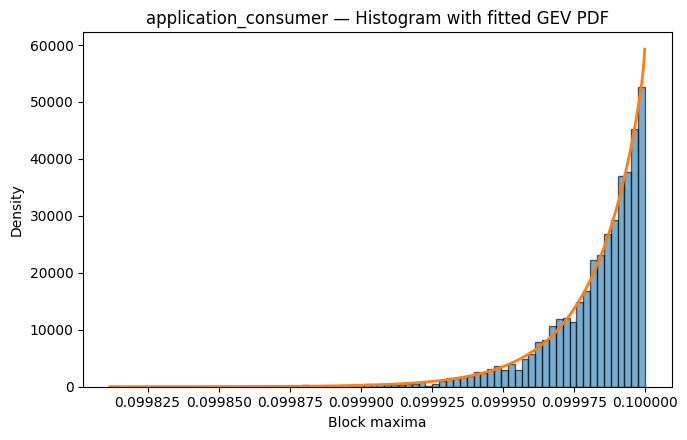

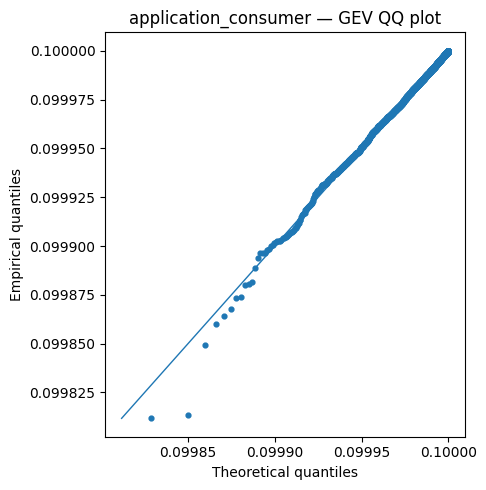

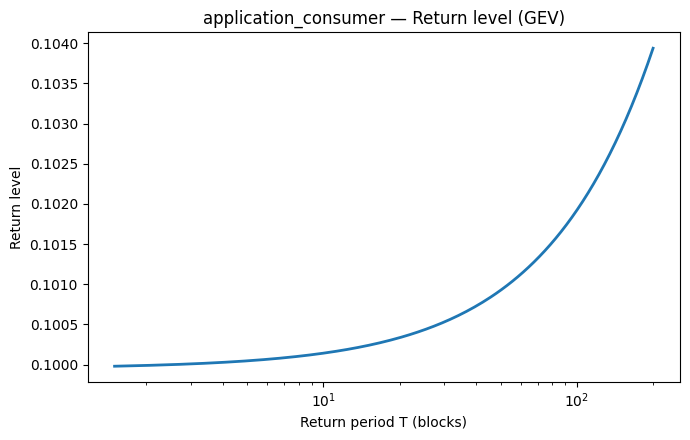

Saved plots in: /Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/merge/


In [50]:
# GEV fit + plots + H0/H1 + plain-English summary

%matplotlib inline

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genextreme, kstest

# --- user inputs ---
CSV_FILE = "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/merge/block_maxima.csv"  # <- change me
METRIC   = "application_consumer"   # or "consumer_producer"
OUTDIR   = "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/merge/"        # <- change me
ALPHA    = 0.05                     # KS test significance level

os.makedirs(OUTDIR, exist_ok=True)

# --- load data ---
df = pd.read_csv(CSV_FILE)
if "metric" not in df or "block_max_value" not in df:
    raise ValueError("CSV must contain 'metric' and 'block_max_value' columns.")

vals = df.loc[df["metric"] == METRIC, "block_max_value"].dropna().astype(float).to_numpy()
if vals.size < 5:
    raise ValueError(f"Need at least 5 block maxima for metric '{METRIC}', found {vals.size}.")

# --- fit GEV (SciPy: returns c, loc, scale; classical xi = -c) ---
c, loc, scale = genextreme.fit(vals)
xi = -c  # classical shape
D, pval = kstest(vals, "genextreme", args=(c, loc, scale))

# Finite endpoint if xi < 0 (i.e., c > 0 in SciPy)
x_max = loc + scale / c if c > 0 else None

def s_and_ms(x):
    return f"{x:.6f} s  ({x*1000:.3f} ms)"

# --- print hypotheses & results ---
print("*** KS Goodness-of-Fit Test (Two-Sided) ***")
print("H0: The block maxima for the chosen metric come from a GEV distribution "
      "with the fitted parameters (c, loc, scale).")
print("H1: The block maxima don't come from that fitted GEV distribution.")
print(f"Significance level α = {ALPHA}")
print(f"KS statistic D = {D:.4f}       (The max CDF gap between data and model (smaller = better))")
print(f"KS statistic p-value = {pval:.4f} (How plausible the model is for the data (bigger = better))")
decision = "Fail to reject H0" if pval >= ALPHA else "Reject H0 (fit not adequate)"
print(f"Decision: {decision}\n")

print("*** Fitted GEV Parameters ***")
print(f"n = {len(vals)}")
print(f"Shape (SciPy) c = {c:.6f}")
print(f"Shape (classical) ξ = -c = {xi:.6f}")
print(f"Location μ = {s_and_ms(loc)}")
print(f"Scale β = {s_and_ms(scale)}")
if x_max is not None:
    print(f"Finite upper endpoint x_max ≈ {s_and_ms(x_max)}")
print()

# --- simple interpretation ---
if xi < 0:
    tail = "Weibull (bounded upper tail)"
    extra = "" #f" There is a finite cap at about {s_and_ms(x_max)}."
elif np.isclose(xi, 0.0, atol=1e-3):
    tail = "Gumbel (light/exponential-type tail)"
    extra = ""
else:
    tail = "Fréchet (heavy/power-law tail)"
    extra = ""
tight = " The small β means the maxima are tightly clustered." if scale < loc * 0.5 else ""

print("*** QQ (quantile-quantile) ***")
print("QQ (quantile-quantile): data vs GEV quantiles — close to 45° = good; bow up = heavier tail; bow down = lighter tail")
print("*** Return level Plot ***")
print("Return level: value expected once every T blocks; steeper = heavier tail; xi<0 → curve caps at a limit")
print("*** Summary ***")
print(f"Tail type: {tail}.{extra}")
print(f"With p = {pval:.3f} > α = {ALPHA}, the GEV fit is {'plausible' if pval >= ALPHA else 'not supported by the KS test'} "
      f"for these block maxima.\n")

# --- Plot 1: Histogram + fitted PDF ---
xs = np.linspace(vals.min(), np.percentile(vals, 99.5), 400)
pdf = genextreme.pdf(xs, c, loc=loc, scale=scale)

plt.figure(figsize=(7,4.5))
plt.hist(vals, bins="auto", density=True, alpha=0.6, edgecolor="black")
plt.plot(xs, pdf, linewidth=2)
plt.title(f"{METRIC} — Histogram with fitted GEV PDF")
plt.xlabel("Block maxima"); plt.ylabel("Density")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, f"{METRIC}_hist_pdf.png"), dpi=150)
plt.show()

# --- Plot 2: QQ plot ---
vv = np.sort(vals)
probs = (np.arange(1, len(vv)+1) - 0.5) / len(vv)
theo = genextreme.ppf(probs, c, loc=loc, scale=scale)

plt.figure(figsize=(5,5))
plt.scatter(theo, vv, s=12)
mn, mx = min(vv.min(), theo.min()), max(vv.max(), theo.max())
plt.plot([mn, mx], [mn, mx], linewidth=1)
plt.title(f"{METRIC} — GEV QQ plot")
plt.xlabel("Theoretical quantiles"); plt.ylabel("Empirical quantiles")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, f"{METRIC}_qq.png"), dpi=150)
plt.show()

# --- Plot 3: Return-level curve (optional but useful) ---
Ts = np.logspace(np.log10(1.5), np.log10(200), 200)  # return period in blocks
p = 1.0 - 1.0 / Ts
eps = 1e-9
if abs(c) < 1e-6:
    rl = loc - scale * np.log(-np.log(np.clip(p, eps, 1-eps)))
else:
    rl = loc + (scale / c) * ((-np.log(np.clip(p, eps, 1-eps)))**(-c) - 1.0)

plt.figure(figsize=(7,4.5))
plt.plot(Ts, rl, linewidth=2)
plt.xscale("log")
plt.title(f"{METRIC} — Return level (GEV)")
plt.xlabel("Return period T (blocks)"); plt.ylabel("Return level")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, f"{METRIC}_return_level.png"), dpi=150)
plt.show()

print(f"Saved plots in: {OUTDIR}")


In [79]:
import os, glob
import pandas as pd
import numpy as np
import re

# ---- edit me ----
ROOT = "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/consumer"   # folder that has subfolders with files
PATTERN = "**/*.parquet"        # try "**/*.csv" for CSV files (or mix: "**/*.parquet", "**/*.csv")
# -----------------

# Find files recursively
paths = sorted(glob.glob(os.path.join(ROOT, PATTERN), recursive=True))
print(f"Found {len(paths)} files matching {PATTERN}")
for p in paths[:5]:
    print(" -", p)
if not paths:
    raise SystemExit("No files found.")

# Helper to read a single file
def read_one(path: str) -> pd.DataFrame:
    if path.endswith(".csv"):
        df = pd.read_csv(path)
    elif path.endswith(".parquet"):
        df = pd.read_parquet(path)  # requires pyarrow or fastparquet
    else:
        raise ValueError(f"Unsupported file type: {path}")
    df["__source__"] = os.path.relpath(path, ROOT)
    return df

# Read and combine
dfs = []
for p in paths:
    try:
        dfs.append(read_one(p))
    except Exception as e:
        print(f"[WARN] Skipping {p}: {e}")

if not dfs:
    raise SystemExit("No readable files.")

df = pd.concat(dfs, ignore_index=True, sort=False)

# See the column labels
print("\nColumn labels:", df.columns.tolist())

# Optional: quick schema and preview
#print("\nDataFrame info:")
#print(df.info())
#print("\nHead:")
#print(df.head())


def to_seconds(col):
    x = pd.to_numeric(col, errors='coerce')
    # Heuristic: decide units by magnitude
    med = np.nanmedian(x)
    if med > 1e14:   # nanoseconds
        x = x / 1e9
    elif med > 1e11: # milliseconds
        x = x / 1e3
    # else: already seconds
    return x

# Convert both columns to seconds
df["producer_ts_s"] = to_seconds(df["producer_timestamp"])
df["app_ts_s"] = to_seconds(df["application_timestamp"])

# Difference in SECONDS (consumer - producer)
df["app_producer_timestamp"] = df["app_ts_s"] - df["producer_ts_s"]

# If you want milliseconds too:
df["app_producer_ms"] = df["app_producer_timestamp"] * 1000.0

print(df.columns)



Found 4838 files matching **/*.parquet
 - /Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/consumer/21-10-19/batch_consumer-sts-4_20250826_031129_548037.parquet
 - /Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/consumer/21-10-19/batch_consumer-sts-4_20250826_031227_673883.parquet
 - /Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/consumer/21-10-19/batch_consumer-sts-4_20250826_031326_149047.parquet
 - /Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/consumer/21-10-19/batch_consumer-sts-4_20250826_031424_771569.parquet
 - /Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/consumer/21-10-19/batch_consumer-sts-4_20250826_031525_353325.parquet

Column labels: ['index', 'producer_timestamp', 'consumer_receive_timestamp', 'application_timestamp'

Found 4838 parquet files under /Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/consumer
Usable files: 4838 | Skipped: 0
Saved per-file maxima CSV -> /Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/merge/block_maxima_application_minus_producer.csv

=== GEV fit on per-file maxima (application_timestamp - producer_timestamp) ===
n = 4838
shape c = -0.825879 (xi = 0.825879)
location mu = 1.104865s (1104.86ms)
scale beta = 0.228337s (228.34ms)
KS: D=0.0606, p=0.0000  -> fit looks off


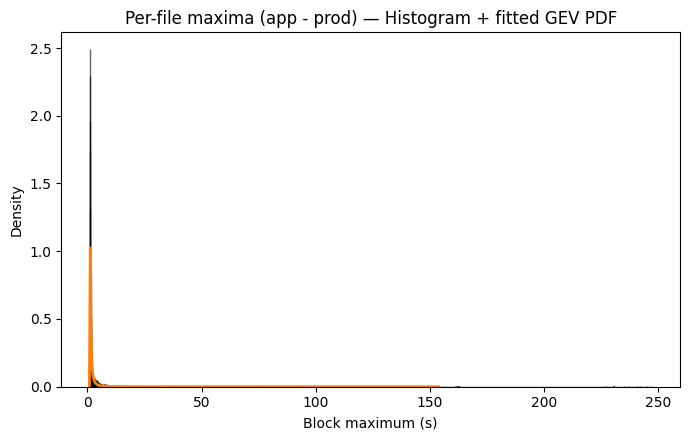

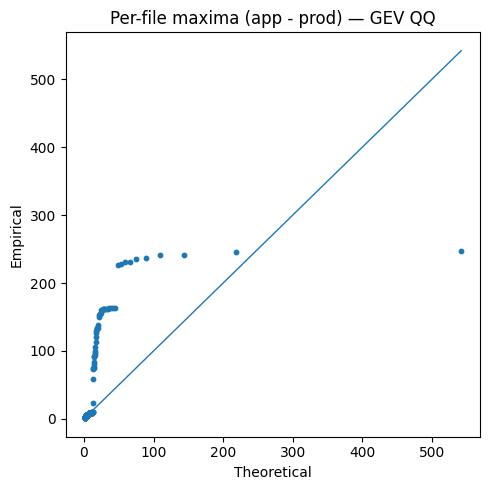

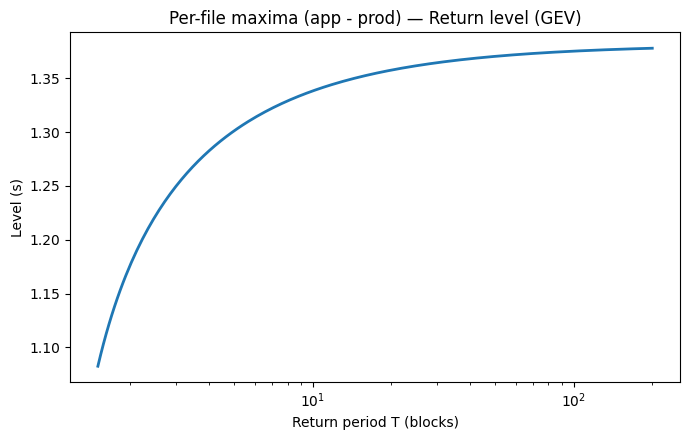


Saved plots and CSV under: /Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/merge


In [80]:
# Read all parquet files under ROOT, compute (application_timestamp - producer_timestamp),
# take MAX per file, then fit GEV + KS, and plot diagnostics.

%matplotlib inline

import os, glob, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genextreme, kstest

# ---------- user settings ----------
ROOT     = "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/consumer"       # <- change me: directory that contains subfolders with parquet files
OUTDIR   = "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/merge"  # <- where to save plots + CSV
APP_COL  = "application_timestamp"    # column name in parquet
PROD_COL = "producer_timestamp"       # column name in parquet
MIN_FILES_FOR_FIT = 5
# -----------------------------------

os.makedirs(OUTDIR, exist_ok=True)

def _collect_parquets(root: str):
    pattern = os.path.join(root, "**", "*.parquet")
    return sorted(glob.glob(pattern, recursive=True))

def _to_seconds(series: pd.Series) -> pd.Series:
    """Convert numeric timestamps to seconds by magnitude (ns/ms/s)."""
    x = pd.to_numeric(series, errors="coerce")
    med = np.nanmedian(x)
    if med > 1e14:      # nanoseconds
        return x / 1e9
    elif med > 1e11:    # milliseconds
        return x / 1e3
    else:               # seconds
        return x

def _read_parquet(path: str) -> pd.DataFrame:
    # requires pyarrow or fastparquet installed
    return pd.read_parquet(path)

def fit_gev(values: np.ndarray):
    v = np.asarray(values, float)
    v = v[np.isfinite(v)]
    if v.size < 5:
        raise ValueError("Not enough maxima to fit GEV (need >= 5).")
    c, loc, scale = genextreme.fit(v)  # SciPy paramization; classical xi = -c
    D, p = kstest(v, 'genextreme', args=(c, loc, scale))
    return c, loc, scale, D, p

def return_level(c, loc, scale, T):
    T = np.asarray(T, float)
    p = 1.0 - 1.0 / T
    eps = 1e-9
    if abs(c) < 1e-6:
        return loc - scale * np.log(-np.log(np.clip(p, eps, 1-eps)))
    return loc + (scale/c) * ((-np.log(np.clip(p, eps, 1-eps)))**(-c) - 1.0)

# ---------- scan + compute per-file maxima ----------
paths = _collect_parquets(ROOT)
print(f"Found {len(paths)} parquet files under {ROOT}")

max_records = []
skipped = 0

for p in paths:
    try:
        df = _read_parquet(p)
    except Exception as e:
        print(f"[WARN] skip unreadable {p}: {e}")
        skipped += 1
        continue

    if APP_COL not in df.columns or PROD_COL not in df.columns:
        # skip if required columns absent
        skipped += 1
        continue

    app_s  = _to_seconds(df[APP_COL])
    prod_s = _to_seconds(df[PROD_COL])
    diff_s = app_s - prod_s

    max_val = pd.to_numeric(diff_s, errors="coerce").max()
    if pd.isna(max_val) or not np.isfinite(max_val):
        skipped += 1
        continue

    max_records.append({"file": os.path.relpath(p, ROOT), "block_max_value": float(max_val)})

print(f"Usable files: {len(max_records)} | Skipped: {skipped}")

if len(max_records) < MIN_FILES_FOR_FIT:
    raise SystemExit(f"Not enough files with valid maxima (< {MIN_FILES_FOR_FIT}).")

max_df = pd.DataFrame(max_records)
max_df["metric"] = "application_minus_producer"  # label the series
max_csv = os.path.join(OUTDIR, "block_maxima_application_minus_producer.csv")
max_df.to_csv(max_csv, index=False)
print(f"Saved per-file maxima CSV -> {max_csv}")

# ---------- fit GEV + KS ----------
vals = max_df["block_max_value"].astype(float).to_numpy()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    c, loc, scale, D, pval = fit_gev(vals)

xi = -c
x_cap = (loc + scale / c) if c > 0 else None  # finite cap if xi<0 (i.e., c>0)

def fmt_s(x): return f"{x:.6f}s ({x*1000:.2f}ms)"

print("\n=== GEV fit on per-file maxima (application_timestamp - producer_timestamp) ===")
print(f"n = {len(vals)}")
print(f"shape c = {c:.6f} (xi = {xi:.6f})")
print(f"location mu = {fmt_s(loc)}")
print(f"scale beta = {fmt_s(scale)}")
if x_cap is not None:
    print(f"finite upper cap ≈ {fmt_s(x_cap)}")
print(f"KS: D={D:.4f}, p={pval:.4f}  -> {'fit looks OK' if pval>=0.05 else 'fit looks off'}")

# ---------- plots ----------
# 1) Histogram + fitted PDF
xs = np.linspace(np.nanmin(vals), np.nanpercentile(vals, 99.5), 400)
pdf = genextreme.pdf(xs, c, loc=loc, scale=scale)
plt.figure(figsize=(7,4.5))
plt.hist(vals, bins="auto", density=True, alpha=0.6, edgecolor="black")
plt.plot(xs, pdf, linewidth=2)
if x_cap is not None:
    plt.axvline(x_cap, linestyle="--"); plt.text(x_cap, plt.ylim()[1]*0.9, "cap", rotation=90, va="top")
plt.title("Per-file maxima (app - prod) — Histogram + fitted GEV PDF")
plt.xlabel("Block maximum (s)"); plt.ylabel("Density")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "hist_pdf.png"), dpi=150)
plt.show()

# 2) QQ plot
v = np.sort(vals); n = len(v)
probs = (np.arange(1, n+1) - 0.5) / n
theo = genextreme.ppf(probs, c, loc=loc, scale=scale)
plt.figure(figsize=(5,5))
plt.scatter(theo, v, s=10)
mn, mx = min(v.min(), theo.min()), max(v.max(), theo.max())
plt.plot([mn, mx], [mn, mx], linewidth=1)
plt.title("Per-file maxima (app - prod) — GEV QQ")
plt.xlabel("Theoretical"); plt.ylabel("Empirical")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "qq.png"), dpi=150)
plt.show()

# 3) Return-level plot
Ts = np.logspace(np.log10(1.5), np.log10(200), 200)
rl = return_level(c, loc, scale, Ts)
plt.figure(figsize=(7,4.5))
plt.plot(Ts, rl, linewidth=2)
if x_cap is not None:
    plt.axhline(x_cap, linestyle="--"); plt.text(Ts[0], x_cap, "cap", va="bottom")
plt.xscale("log")
plt.title("Per-file maxima (app - prod) — Return level (GEV)")
plt.xlabel("Return period T (blocks)"); plt.ylabel("Level (s)")
plt.tight_layout()
plt.savefig(os.path.join(OUTDIR, "return_level.png"), dpi=150)
plt.show()

print(f"\nSaved plots and CSV under: {OUTDIR}")


Found 4838 parquet files
Total rows used: 24190000  | Skipped files: 0
Threshold u = 0.674041s  | exceedances n_u = 1209498  (rate ζ_u = 0.0500)
GPD fit: xi=1.718658, sigma=0.107505 (loc fixed at 0)
KS on excesses: D=0.1480, p=0.0000  -> warning


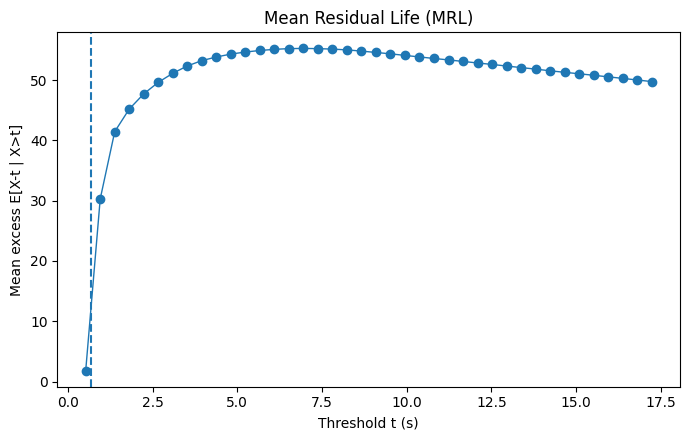

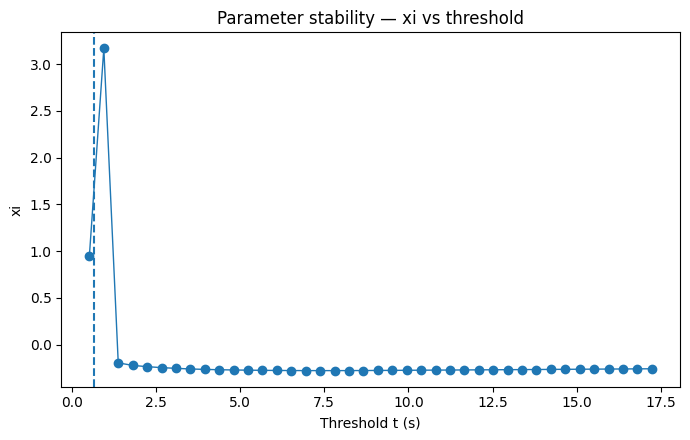

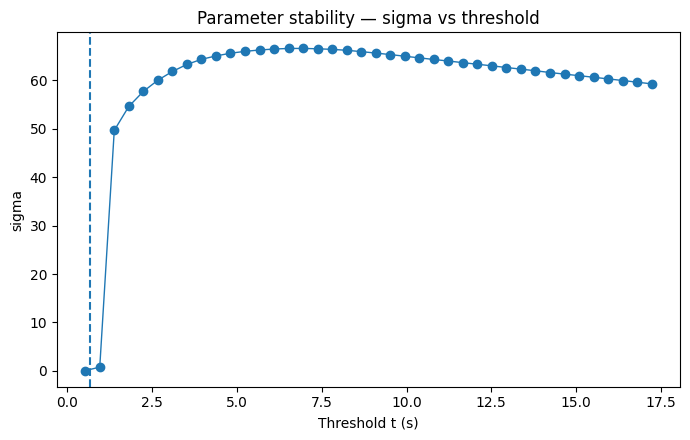

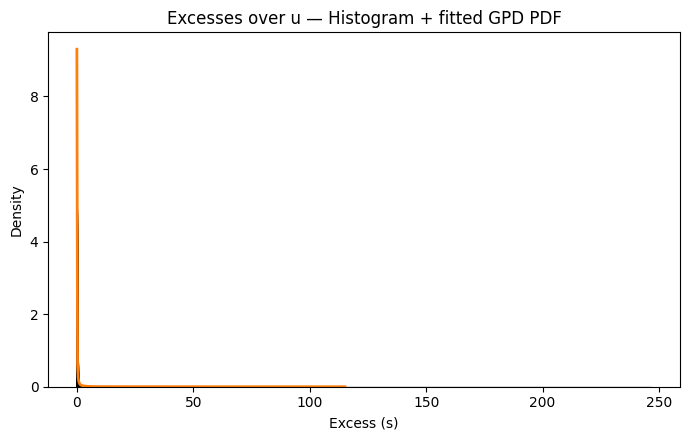

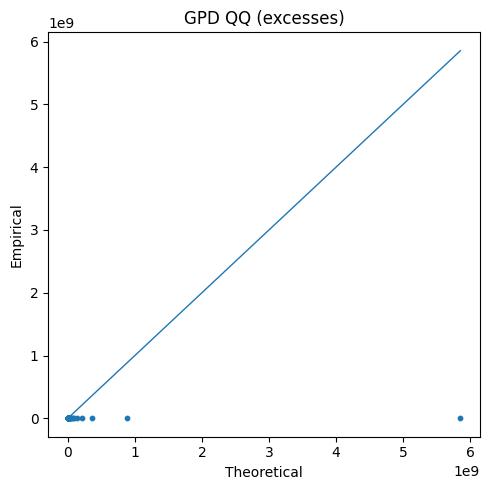

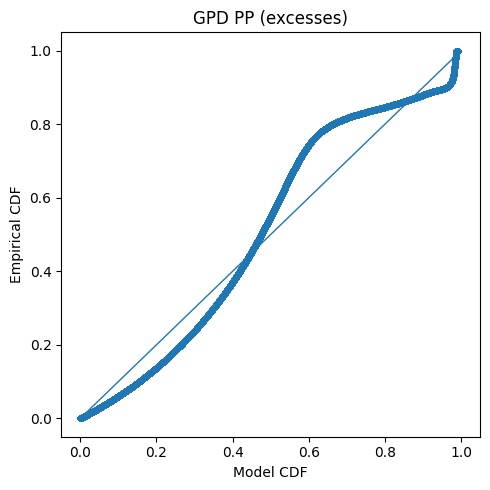

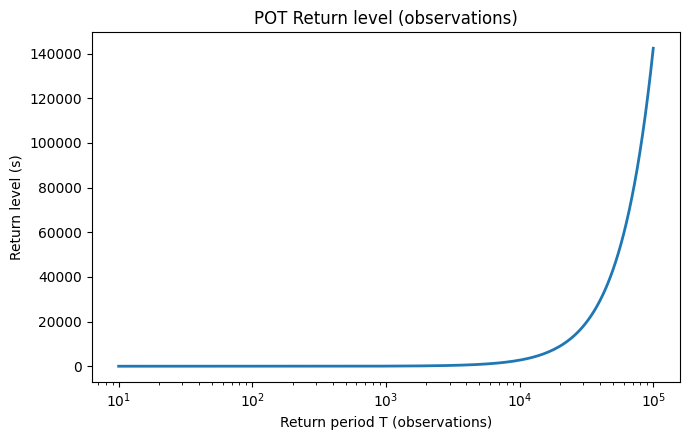


Saved plots + gpd_fit_summary.json in: /Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/merge/pot_gpd_app_minus_prod
KS D = max CDF gap between data and model (smaller is better)
KS p = how plausible the model is for the data (bigger = better)
Return level at T = value exceeded about once every T observations


In [81]:
# POT / GPD fit for producer→application latency: (application_timestamp - producer_timestamp)
# - Reads all .parquet under ROOT (recursively)
# - Converts timestamps to seconds by magnitude (ns/ms/s)
# - Builds exceedances over threshold u (default: 95th percentile)
# - Fits GPD, prints stats, and shows + saves: MRL, param stability, hist+PDF, QQ, PP, return-level
# Requires: numpy, pandas, matplotlib, scipy, pyarrow (or fastparquet)

%matplotlib inline

import os, glob, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genpareto, kstest

# ----------------- user config -----------------
ROOT     = "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/consumer"       # <- change me: directory that contains subfolders with parquet files
OUTDIR   = "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/merge/pot_gpd_app_minus_prod"
APP_COL  = "application_timestamp"
PROD_COL = "producer_timestamp"

# threshold choice:
U_QUANTILE = 0.95       # use 95th percentile as threshold
U_VALUE    = None       # OR set a fixed numeric threshold in seconds (overrides U_QUANTILE)
MIN_EXCESS = 50         # need at least this many exceedances to fit
# (optional) filter out negatives (clock skew)
DROP_NEGATIVE = True
# ------------------------------------------------

os.makedirs(OUTDIR, exist_ok=True)

def _collect_parquets(root: str):
    return sorted(glob.glob(os.path.join(root, "**", "*.parquet"), recursive=True))

def _read_parquet(path: str) -> pd.DataFrame:
    return pd.read_parquet(path)

def _to_seconds(series: pd.Series) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce")
    med = np.nanmedian(x)
    if med > 1e14:   # nanoseconds
        return x / 1e9
    elif med > 1e11: # milliseconds
        return x / 1e3
    else:            # seconds
        return x

# ------- load all parquet rows and compute latency -------
paths = _collect_parquets(ROOT)
if not paths:
    raise SystemExit(f"No parquet files found under: {ROOT}")
print(f"Found {len(paths)} parquet files")

lat_parts = []
skipped = 0
for p in paths:
    try:
        df = _read_parquet(p)
        if APP_COL not in df or PROD_COL not in df:
            skipped += 1
            continue
        app_s  = _to_seconds(df[APP_COL])
        prod_s = _to_seconds(df[PROD_COL])
        lat = app_s - prod_s
        if DROP_NEGATIVE:
            lat = lat[lat >= 0]
        lat_parts.append(lat.values.astype(float))
    except Exception as e:
        print(f"[WARN] Skip {p}: {e}")
        skipped += 1

if not lat_parts:
    raise SystemExit("No usable rows with both timestamps.")
lat_all = np.concatenate(lat_parts)
lat_all = lat_all[np.isfinite(lat_all)]
print(f"Total rows used: {lat_all.size}  | Skipped files: {skipped}")

# ------------- choose threshold and build exceedances -------------
if U_VALUE is None:
    u = np.nanquantile(lat_all, U_QUANTILE)
else:
    u = float(U_VALUE)
excess = lat_all[lat_all > u] - u
n_total = lat_all.size
n_u = excess.size
zeta_u = n_u / n_total  # empirical exceedance rate

if n_u < MIN_EXCESS:
    raise SystemExit(f"Too few exceedances above u={u:.6f}s (n_u={n_u} < {MIN_EXCESS}). Increase U_QUANTILE or lower U_VALUE.")

print(f"Threshold u = {u:.6f}s  | exceedances n_u = {n_u}  (rate ζ_u = {zeta_u:.4f})")

# ------------- fit GPD on excesses -------------
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # fix loc=0 for true excesses
    c, loc, scale = genpareto.fit(excess, floc=0.0)
xi = c
sigma = scale
print(f"GPD fit: xi={xi:.6f}, sigma={sigma:.6f} (loc fixed at 0)")

# ------------- simple goodness check (KS; not very tail-sensitive) -------------
D, pval = kstest(excess, 'genpareto', args=(xi, 0.0, sigma))
print(f"KS on excesses: D={D:.4f}, p={pval:.4f}  -> {'OK' if pval>=0.05 else 'warning'}")

# ===================== DIAGNOSTIC PLOTS =====================

# (1) Mean Residual Life (MRL) plot: t ↦ mean(Y - t | Y>t)
ts = np.linspace(np.nanpercentile(lat_all, 80), np.nanpercentile(lat_all, 99.5), 40)
mrl = []
for t in ts:
    ex = lat_all[lat_all > t] - t
    mrl.append(np.nan if ex.size == 0 else np.mean(ex))
plt.figure(figsize=(7,4.5))
plt.plot(ts, mrl, marker='o', linewidth=1)
plt.axvline(u, linestyle='--')
plt.title("Mean Residual Life (MRL)"); plt.xlabel("Threshold t (s)"); plt.ylabel("Mean excess E[X-t | X>t]")
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "mrl.png"), dpi=150); plt.show()

# (2) Parameter stability: fit xi, sigma over a range of thresholds
xis, sigmas = [], []
for t in ts:
    ex = lat_all[lat_all > t] - t
    if ex.size < MIN_EXCESS:
        xis.append(np.nan); sigmas.append(np.nan); continue
    cc, ll, ss = genpareto.fit(ex, floc=0.0)
    xis.append(cc); sigmas.append(ss)
plt.figure(figsize=(7,4.5))
plt.plot(ts, xis, marker='o', linewidth=1)
plt.axvline(u, linestyle='--')
plt.title("Parameter stability — xi vs threshold"); plt.xlabel("Threshold t (s)"); plt.ylabel("xi")
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "param_stability_xi.png"), dpi=150); plt.show()

plt.figure(figsize=(7,4.5))
plt.plot(ts, sigmas, marker='o', linewidth=1)
plt.axvline(u, linestyle='--')
plt.title("Parameter stability — sigma vs threshold"); plt.xlabel("Threshold t (s)"); plt.ylabel("sigma")
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "param_stability_sigma.png"), dpi=150); plt.show()

# (3) Histogram of excesses + fitted GPD PDF
xs = np.linspace(np.nanmin(excess), np.nanpercentile(excess, 99.5), 400)
pdf = genpareto.pdf(xs, xi, loc=0.0, scale=sigma)
plt.figure(figsize=(7,4.5))
plt.hist(excess, bins="auto", density=True, alpha=0.6, edgecolor="black")
plt.plot(xs, pdf, linewidth=2)
plt.title("Excesses over u — Histogram + fitted GPD PDF")
plt.xlabel("Excess (s)"); plt.ylabel("Density")
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "excess_hist_pdf.png"), dpi=150); plt.show()

# (4) QQ plot (excess quantiles vs GPD quantiles)
ex = np.sort(excess); n = ex.size
probs = (np.arange(1, n+1) - 0.5) / n
theo_ex = genpareto.ppf(probs, xi, loc=0.0, scale=sigma)
plt.figure(figsize=(5,5))
plt.scatter(theo_ex, ex, s=10)
mn, mx = float(np.nanmin([ex.min(), theo_ex.min()])), float(np.nanmax([ex.max(), theo_ex.max()]))
plt.plot([mn, mx], [mn, mx], linewidth=1)
plt.title("GPD QQ (excesses)")
plt.xlabel("Theoretical"); plt.ylabel("Empirical")
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "qq.png"), dpi=150); plt.show()

# (5) PP plot (empirical CDF vs model CDF for excesses)
F_emp = np.arange(1, n+1) / (n+1)
F_theo = genpareto.cdf(ex, xi, loc=0.0, scale=sigma)
plt.figure(figsize=(5,5))
plt.scatter(F_theo, F_emp, s=10)
plt.plot([0,1],[0,1], linewidth=1)
plt.title("GPD PP (excesses)")
plt.xlabel("Model CDF"); plt.ylabel("Empirical CDF")
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "pp.png"), dpi=150); plt.show()

# (6) Return-level plot for POT (original scale)
# Using: P(X > z) ≈ (n_u / n_total) * (1 + xi (z - u)/sigma)^(-1/xi)  for z ≥ u
# So 1/T = P(X > z_T) ⇒ z_T = u + (sigma/xi) * ((T * n_u / n_total)^xi - 1)  (xi != 0)
Ts = np.logspace(np.log10(10), np.log10(1e5), 200)  # return period in "number of observations"
if abs(xi) < 1e-8:
    rl = u + sigma * np.log(Ts * zeta_u)
else:
    rl = u + (sigma/xi) * ((Ts * zeta_u) ** xi - 1.0)

plt.figure(figsize=(7,4.5))
plt.plot(Ts, rl, linewidth=2)
plt.xscale("log")
plt.title("POT Return level (observations)")
plt.xlabel("Return period T (observations)"); plt.ylabel("Return level (s)")
plt.tight_layout(); plt.savefig(os.path.join(OUTDIR, "return_level.png"), dpi=150); plt.show()

# -------- save a tiny JSON with fit summary --------
summary = {
    "n_total": int(n_total),
    "threshold_u_s": float(u),
    "n_exceed": int(n_u),
    "exceed_rate": float(zeta_u),
    "xi": float(xi),
    "sigma": float(sigma),
    "KS_D": float(D),
    "KS_p": float(pval),
}
with open(os.path.join(OUTDIR, "gpd_fit_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print(f"\nSaved plots + gpd_fit_summary.json in: {OUTDIR}")

# ------------- Tiny helper prints (drop-in) -------------
print("KS D = max CDF gap between data and model (smaller is better)")
print("KS p = how plausible the model is for the data (bigger = better)")
print("Return level at T = value exceeded about once every T observations")


Found 4838 parquet files
Total rows used: 24190000  | Skipped files: 0
Threshold u = 0.674041s  | exceedances n_u = 1209498  (rate ζ_u = 0.0500)
GPD fit: xi=1.718658, sigma=0.107505
KS on excesses: D=0.1480, p=0.0000  -> warning


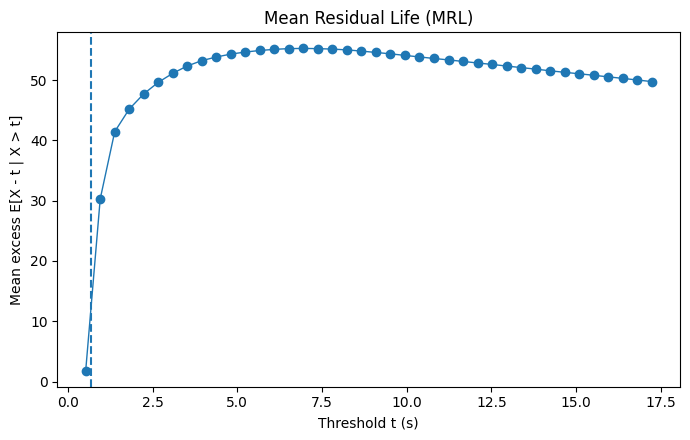

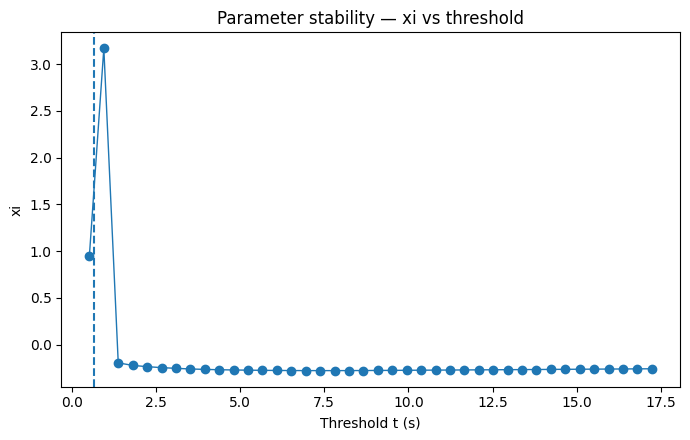

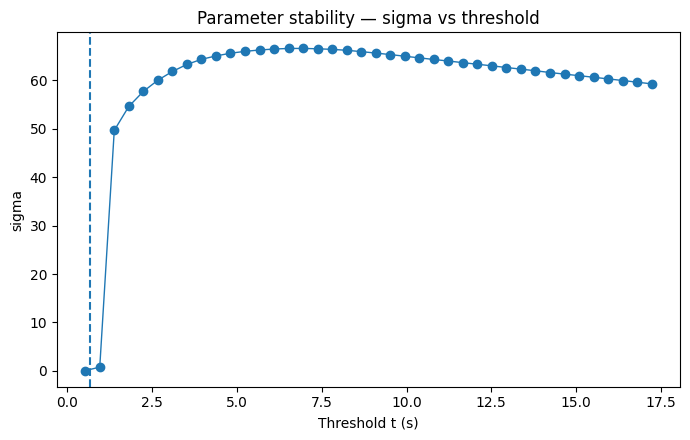

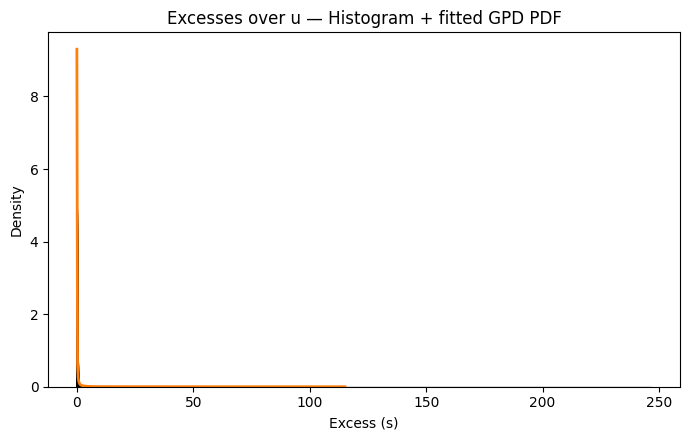

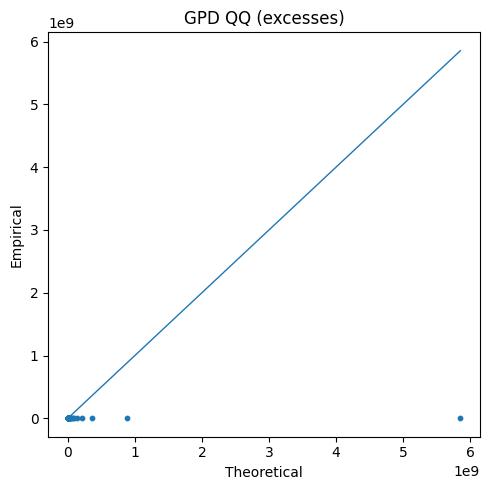

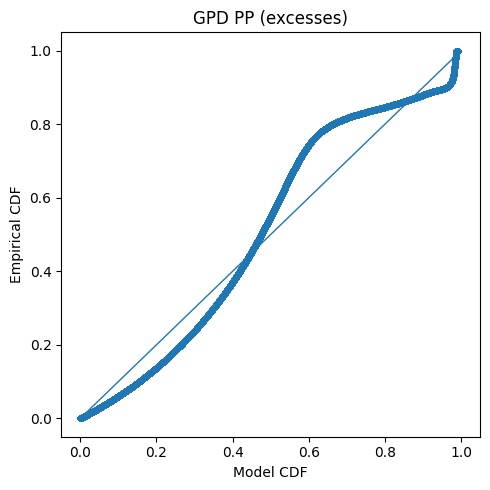

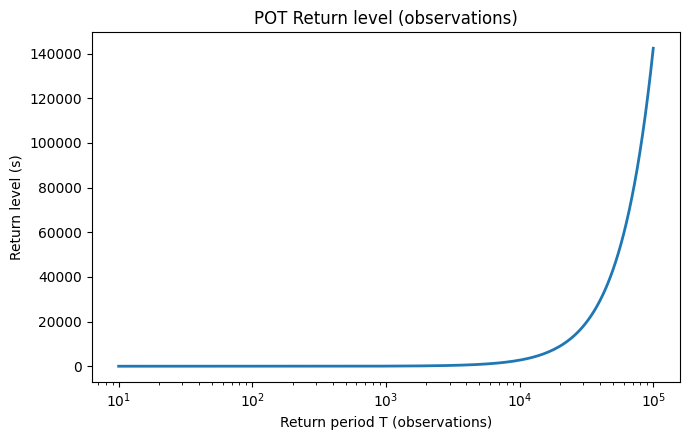


Threshold sweep (no declustering):
       q          u   n_exc        xi      sigma      KS_D  KS_p
0  0.970   0.770385  725700  2.471395   0.091928  0.113096   0.0
1  0.980   0.835982  483800  3.260103   0.097712  0.106996   0.0
2  0.990   1.016901  241900  2.533453   2.208536  0.203200   0.0
3  0.995  17.230689  120950 -0.257378  59.291075  0.161305   0.0
Saved sweep CSV -> /tmp/pot_gpd_app_minus_prod/threshold_sweep.csv

Declustered clusters: 9106 from 483800 exceedances (u_dc=0.835982s, gap=2.0s)
GPD (declustered): xi=0.242006, sigma=0.186551, KS D=0.1431, p=2.965e-163


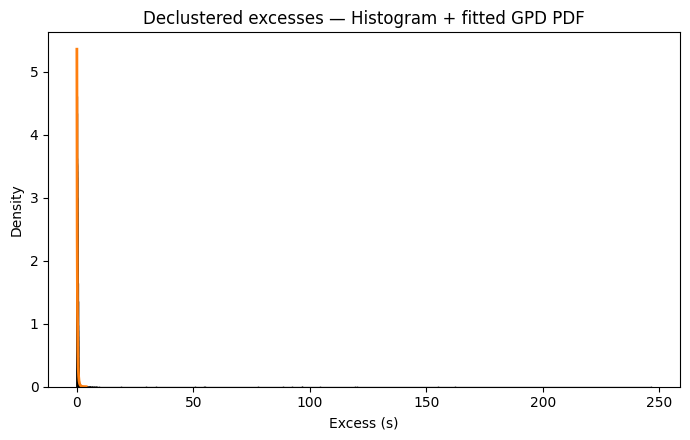

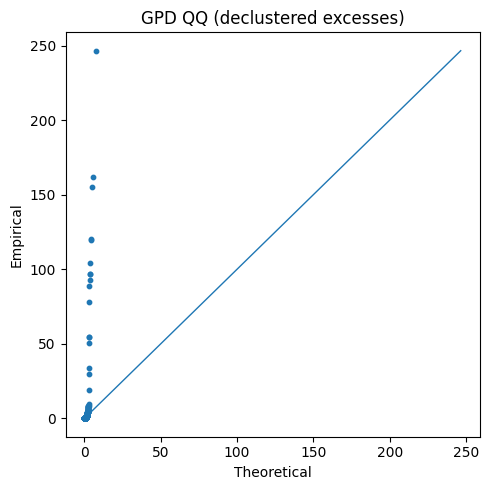

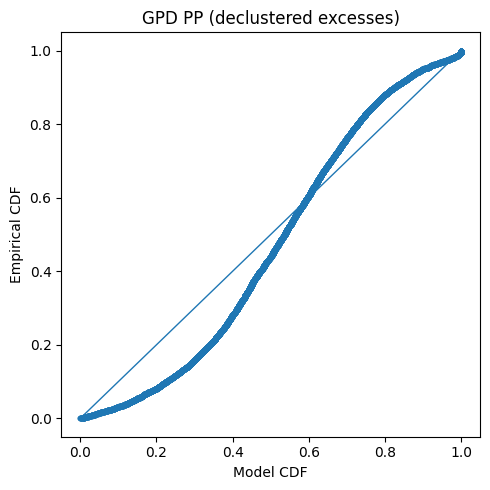

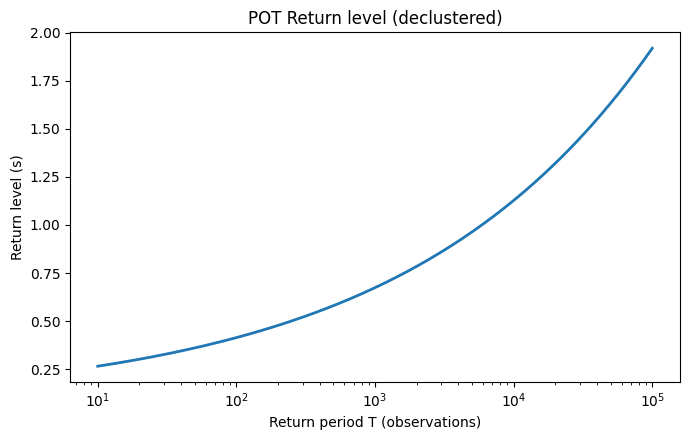


Saved outputs to: /tmp/pot_gpd_app_minus_prod
KS D = max CDF gap between data and model (smaller is better)
KS p = how plausible the model is for the data (bigger = better)
Return level at T = value exceeded about once every T observations


In [83]:
# POT / GPD for producer→application latency
# - Reads ALL .parquet under ROOT (recursively)
# - Latency = application_timestamp - producer_timestamp  (auto ns/ms→seconds)
# - Fit GPD on exceedances over threshold u (95% by default) + KS, QQ, PP, Return-level
# - Threshold sweep (97/98/99/99.5%)
# - Time-declustered GPD (keep cluster maxima separated by GAP seconds)
# Requires: numpy, pandas, matplotlib, scipy, pyarrow (or fastparquet)

%matplotlib inline

import os, glob, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genpareto, kstest

# ----------------- user config -----------------
ROOT     = "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/consumer"       # <- change me: directory that contains subfolders with parquet files
OUTDIR   = "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/merge/pot_gpd_app_minus_prod"
PROD_COL  = "producer_timestamp"
OUTDIR    = "/tmp/pot_gpd_app_minus_prod"

# Base POT fit:
U_QUANTILE   = 0.95       # use 95th percentile as u (set U_VALUE to override)
U_VALUE      = None       # numeric threshold in seconds (wins over U_QUANTILE)
MIN_EXCESS   = 100        # need at least this many exceedances

# Threshold sweep (no declustering):
SWEEP_QUANTS = [0.97, 0.98, 0.99, 0.995]

# Time declustering:
DECLUSTER_GAP_SEC = 2.0   # new cluster if time gap > this (seconds)
U_DECLUST_Q       = 0.98  # threshold for declustering (use quantile of all latencies)
U_DECLUST_VALUE   = None  # or numeric value (seconds), overrides U_DECLUST_Q

# Data cleaning:
DROP_NEGATIVE = True      # drop negative latencies (clock skew etc.)
# ------------------------------------------------

os.makedirs(OUTDIR, exist_ok=True)

def _collect_parquets(root: str):
    return sorted(glob.glob(os.path.join(root, "**", "*.parquet"), recursive=True))

def _read_parquet(path: str) -> pd.DataFrame:
    return pd.read_parquet(path)

def _to_seconds(series: pd.Series) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce")
    med = np.nanmedian(x)
    if med > 1e14:   # nanoseconds
        return x / 1e9
    elif med > 1e11: # milliseconds
        return x / 1e3
    else:            # seconds
        return x

def _fit_gpd(excess: np.ndarray):
    v = np.asarray(excess, float)
    v = v[np.isfinite(v)]
    if v.size < 5:
        raise ValueError("Not enough exceedances to fit GPD (need >= 5).")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        c, loc, scale = genpareto.fit(v, floc=0.0)  # loc fixed at 0 for true excesses
    D, p = kstest(v, 'genpareto', args=(c, 0.0, scale))
    return c, scale, D, p

def _save_hist_pdf(vals, xi, sigma, out_png, title):
    xs = np.linspace(np.nanmin(vals), np.nanpercentile(vals, 99.5), 400)
    pdf = genpareto.pdf(xs, xi, loc=0.0, scale=sigma)
    plt.figure(figsize=(7,4.5))
    plt.hist(vals, bins="auto", density=True, alpha=0.6, edgecolor="black")
    plt.plot(xs, pdf, linewidth=2)
    plt.title(title); plt.xlabel("Excess (s)"); plt.ylabel("Density")
    plt.tight_layout(); plt.savefig(out_png, dpi=150); plt.show()

def _save_qq(excess, xi, sigma, out_png, title):
    ex = np.sort(np.asarray(excess, float))
    n = len(ex)
    probs = (np.arange(1, n+1) - 0.5) / n
    theo = genpareto.ppf(probs, xi, loc=0.0, scale=sigma)
    plt.figure(figsize=(5,5))
    plt.scatter(theo, ex, s=10)
    mn, mx = float(np.nanmin([ex.min(), theo.min()])), float(np.nanmax([ex.max(), theo.max()]))
    plt.plot([mn, mx], [mn, mx], linewidth=1)
    plt.title(title); plt.xlabel("Theoretical"); plt.ylabel("Empirical")
    plt.tight_layout(); plt.savefig(out_png, dpi=150); plt.show()

def _save_pp(excess, xi, sigma, out_png, title):
    ex = np.sort(np.asarray(excess, float))
    n = len(ex)
    F_emp = np.arange(1, n+1) / (n+1)
    F_theo = genpareto.cdf(ex, xi, loc=0.0, scale=sigma)
    plt.figure(figsize=(5,5))
    plt.scatter(F_theo, F_emp, s=10)
    plt.plot([0,1],[0,1], linewidth=1)
    plt.title(title); plt.xlabel("Model CDF"); plt.ylabel("Empirical CDF")
    plt.tight_layout(); plt.savefig(out_png, dpi=150); plt.show()

def _save_return_level_pot(u, xi, sigma, zeta_u, out_png, title):
    # Using: P(X > z) ≈ zeta_u * (1 + xi*(z-u)/sigma)^(-1/xi), for z >= u
    # 1/T = P(X > z_T) => z_T = u + (sigma/xi)*((T*zeta_u)^xi - 1)  for xi != 0
    Ts = np.logspace(np.log10(10), np.log10(1e5), 200)  # "observations" return period
    if abs(xi) < 1e-9:
        rl = u + sigma * np.log(Ts * zeta_u)
    else:
        rl = u + (sigma/xi) * ((Ts * zeta_u)**xi - 1.0)
    plt.figure(figsize=(7,4.5))
    plt.plot(Ts, rl, linewidth=2)
    plt.xscale("log")
    plt.title(title); plt.xlabel("Return period T (observations)"); plt.ylabel("Return level (s)")
    plt.tight_layout(); plt.savefig(out_png, dpi=150); plt.show()

def _save_mrl_and_stability(lat_all, u, out_dir):
    # MRL
    ts = np.linspace(np.nanpercentile(lat_all, 80), np.nanpercentile(lat_all, 99.5), 40)
    mrl = []
    for t in ts:
        ex = lat_all[lat_all > t] - t
        mrl.append(np.nan if ex.size == 0 else np.mean(ex))
    plt.figure(figsize=(7,4.5))
    plt.plot(ts, mrl, marker='o', linewidth=1)
    plt.axvline(u, linestyle='--')
    plt.title("Mean Residual Life (MRL)"); plt.xlabel("Threshold t (s)"); plt.ylabel("Mean excess E[X - t | X > t]")
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, "mrl.png"), dpi=150); plt.show()

    # Parameter stability
    xis, sigmas = [], []
    for t in ts:
        ex = lat_all[lat_all > t] - t
        if ex.size < MIN_EXCESS:
            xis.append(np.nan); sigmas.append(np.nan); continue
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            cc, ll, ss = genpareto.fit(ex, floc=0.0)
        xis.append(cc); sigmas.append(ss)

    plt.figure(figsize=(7,4.5))
    plt.plot(ts, xis, marker='o', linewidth=1)
    plt.axvline(u, linestyle='--')
    plt.title("Parameter stability — xi vs threshold"); plt.xlabel("Threshold t (s)"); plt.ylabel("xi")
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, "param_stability_xi.png"), dpi=150); plt.show()

    plt.figure(figsize=(7,4.5))
    plt.plot(ts, sigmas, marker='o', linewidth=1)
    plt.axvline(u, linestyle='--')
    plt.title("Parameter stability — sigma vs threshold"); plt.xlabel("Threshold t (s)"); plt.ylabel("sigma")
    plt.tight_layout(); plt.savefig(os.path.join(out_dir, "param_stability_sigma.png"), dpi=150); plt.show()

# -------------------- load all parquet rows --------------------
paths = _collect_parquets(ROOT)
if not paths: raise SystemExit(f"No parquet files found under: {ROOT}")
print(f"Found {len(paths)} parquet files")

lat_parts, time_parts = [], []
skipped = 0
for p in paths:
    try:
        df = _read_parquet(p)
        if APP_COL not in df or PROD_COL not in df:
            skipped += 1
            continue
        app_s  = _to_seconds(df[APP_COL])
        prod_s = _to_seconds(df[PROD_COL])
        lat = app_s - prod_s
        if DROP_NEGATIVE:
            mask = (lat >= 0)
            lat = lat[mask]; app_s = app_s[mask]
        lat_parts.append(lat.values.astype(float))
        time_parts.append(app_s.values.astype(float))   # use application time as the time axis
    except Exception as e:
        print(f"[WARN] Skip {p}: {e}")
        skipped += 1

if not lat_parts:
    raise SystemExit("No usable rows with both timestamps.")
lat_all = np.concatenate(lat_parts); lat_all = lat_all[np.isfinite(lat_all)]
app_times_all = np.concatenate(time_parts); app_times_all = app_times_all[np.isfinite(app_times_all)]
print(f"Total rows used: {lat_all.size}  | Skipped files: {skipped}")

# -------------------- base POT fit (no declustering) --------------------
u = float(U_VALUE) if U_VALUE is not None else float(np.nanquantile(lat_all, U_QUANTILE))
excess = lat_all[lat_all > u] - u
n_total, n_u = lat_all.size, excess.size
zeta_u = n_u / n_total
print(f"Threshold u = {u:.6f}s  | exceedances n_u = {n_u}  (rate ζ_u = {zeta_u:.4f})")
if n_u < MIN_EXCESS: raise SystemExit(f"Too few exceedances above u (need >= {MIN_EXCESS}).")

xi, sigma, D, pval = _fit_gpd(excess)
print(f"GPD fit: xi={xi:.6f}, sigma={sigma:.6f}")
print(f"KS on excesses: D={D:.4f}, p={pval:.4f}  -> {'OK' if pval>=0.05 else 'warning'}")

# Diagnostics + plots
_save_mrl_and_stability(lat_all, u, OUTDIR)
_save_hist_pdf(excess, xi, sigma, os.path.join(OUTDIR, "excess_hist_pdf.png"),
               "Excesses over u — Histogram + fitted GPD PDF")
_save_qq(excess, xi, sigma, os.path.join(OUTDIR, "qq.png"),
         "GPD QQ (excesses)")
_save_pp(excess, xi, sigma, os.path.join(OUTDIR, "pp.png"),
         "GPD PP (excesses)")
_save_return_level_pot(u, xi, sigma, zeta_u, os.path.join(OUTDIR, "return_level.png"),
                       "POT Return level (observations)")

with open(os.path.join(OUTDIR, "gpd_fit_summary.json"), "w") as f:
    json.dump({"u_s": u, "n_total": int(n_total), "n_exceed": int(n_u), "exceed_rate": float(zeta_u),
               "xi": float(xi), "sigma": float(sigma), "KS_D": float(D), "KS_p": float(pval)}, f, indent=2)

# -------------------- threshold sweep (no declustering) --------------------
rows = []
for q in SWEEP_QUANTS:
    u_q = float(np.nanquantile(lat_all, q))
    exc = lat_all[lat_all > u_q] - u_q
    if exc.size < MIN_EXCESS:
        rows.append(dict(q=q, u=u_q, n_exc=int(exc.size), xi=np.nan, sigma=np.nan, KS_D=np.nan, KS_p=np.nan))
        continue
    xi_q, sig_q, D_q, p_q = _fit_gpd(exc)
    rows.append(dict(q=q, u=u_q, n_exc=int(exc.size), xi=xi_q, sigma=sig_q, KS_D=D_q, KS_p=p_q))

sweep_df = pd.DataFrame(rows)
sweep_csv = os.path.join(OUTDIR, "threshold_sweep.csv")
sweep_df.to_csv(sweep_csv, index=False)
print("\nThreshold sweep (no declustering):")
print(sweep_df)
print(f"Saved sweep CSV -> {sweep_csv}")

# -------------------- time declustering --------------------
u_dc = float(U_DECLUST_VALUE) if U_DECLUST_VALUE is not None else float(np.nanquantile(lat_all, U_DECLUST_Q))
mask = lat_all > u_dc
ex_t = app_times_all[mask]
ex_v = lat_all[mask] - u_dc

# Sort by time
ord_idx = np.argsort(ex_t)
ex_t = ex_t[ord_idx]; ex_v = ex_v[ord_idx]

# Cluster by gap
clusters_max = []
if ex_v.size:
    start = 0
    for i in range(1, ex_v.size):
        if (ex_t[i] - ex_t[i-1]) > DECLUSTER_GAP_SEC:
            clusters_max.append(ex_v[start:i].max())
            start = i
    clusters_max.append(ex_v[start:].max())

clusters_max = np.asarray(clusters_max, float)
print(f"\nDeclustered clusters: {len(clusters_max)} from {mask.sum()} exceedances (u_dc={u_dc:.6f}s, gap={DECLUSTER_GAP_SEC}s)")

if clusters_max.size >= MIN_EXCESS:
    xi_dc, sigma_dc, D_dc, p_dc = _fit_gpd(clusters_max)
    print(f"GPD (declustered): xi={xi_dc:.6f}, sigma={sigma_dc:.6f}, KS D={D_dc:.4f}, p={p_dc:.4g}")

    # Plots for declustered
    _save_hist_pdf(clusters_max, xi_dc, sigma_dc,
                   os.path.join(OUTDIR, "declust_excess_hist_pdf.png"),
                   "Declustered excesses — Histogram + fitted GPD PDF")
    _save_qq(clusters_max, xi_dc, sigma_dc,
             os.path.join(OUTDIR, "declust_qq.png"),
             "GPD QQ (declustered excesses)")
    _save_pp(clusters_max, xi_dc, sigma_dc,
             os.path.join(OUTDIR, "declust_pp.png"),
             "GPD PP (declustered excesses)")

    # Return levels for declustered (use exceedance rate based on cluster counts)
    zeta_dc = len(clusters_max) / n_total
    _save_return_level_pot(u_dc, xi_dc, sigma_dc, zeta_dc,
                           os.path.join(OUTDIR, "declust_return_level.png"),
                           "POT Return level (declustered)")

    with open(os.path.join(OUTDIR, "gpd_fit_summary_declust.json"), "w") as f:
        json.dump({"u_s": u_dc, "gap_s": DECLUSTER_GAP_SEC, "n_total": int(n_total),
                   "n_clusters": int(len(clusters_max)), "cluster_rate": float(zeta_dc),
                   "xi": float(xi_dc), "sigma": float(sigma_dc),
                   "KS_D": float(D_dc), "KS_p": float(p_dc)}, f, indent=2)
else:
    print("Not enough declustered clusters to fit; try lowering gap or threshold.")

print(f"\nSaved outputs to: {OUTDIR}")

# Handy one-liners for your report:
print("KS D = max CDF gap between data and model (smaller is better)")
print("KS p = how plausible the model is for the data (bigger = better)")
print("Return level at T = value exceeded about once every T observations")


Sample size used: 2000000


/Users/soheila/.pyenv/versions/3.8.18/lib/python3.8/site-packages/scipy/stats/_hypotests.py:395: RuntimeWarning: overflow encountered in scalar multiply
  e3 = 2 * (m + 2) * gamma(k + 3/2) * _ed3((4 * k + 5) / sx) / (12 * y2)
/Users/soheila/.pyenv/versions/3.8.18/lib/python3.8/site-packages/scipy/stats/_hypotests.py:393: RuntimeWarning: overflow encountered in scalar multiply
  e1 = m * gamma(k + 1/2) * _ed2((4 * k + 3)/sx) / (9 * y1)
/Users/soheila/.pyenv/versions/3.8.18/lib/python3.8/site-packages/scipy/stats/_hypotests.py:396: RuntimeWarning: overflow encountered in scalar multiply
  e4 = 7 * m * gamma(k + 1/2) * _ed2((4 * k + 1) / sx) / (144 * y1)
/Users/soheila/.pyenv/versions/3.8.18/lib/python3.8/site-packages/scipy/stats/_hypotests.py:397: RuntimeWarning: overflow encountered in scalar multiply
  e5 = 7 * m * gamma(k + 1/2) * _ed2((4 * k + 5) / sx) / (144 * y1)
/Users/soheila/.pyenv/versions/3.8.18/lib/python3.8/site-packages/scipy/stats/_hypotests.py:406: RuntimeWarning: invali

,dist,n,k,AIC,BIC,KS_D,KS_p,CVM,CVM_p
7,burr,2000000,4,-7.668041e+05,-7.667541e+05,0.055483,0.0,1375.783072,2.510699e-07
6,fisk,2000000,3,-7.077523e+05,-7.077147e+05,0.072788,0.0,2559.676336,4.531390e-07
1,lognorm,2000000,3,-2.626916e+05,-2.626541e+05,0.115147,0.0,6157.170768,0.000000e+00
8,gengamma,2000000,4,1.116168e+06,1.116218e+06,0.201622,0.0,38272.801378,0.000000e+00
4,weibull_min,2000000,3,2.124403e+06,2.124440e+06,0.368970,0.0,107030.161496,0.000000e+00
2,expon,2000000,2,2.606742e+06,2.606767e+06,0.358364,0.0,69164.655243,0.000000e+00
0,norm,2000000,2,1.225406e+07,1.225408e+07,0.472805,0.0,149783.248439,0.000000e+00
3,gamma,2000000,3,1.335156e+07,1.335159e+07,0.941040,0.0,613766.193922,0.000000e+00
9,weibull_max,2000000,3,inf,inf,0.885621,0.0,474581.857201,0.000000e+00
5,logistic,2000000,2,NaN,NaN,NaN,NaN,NaN,1.000000e+00


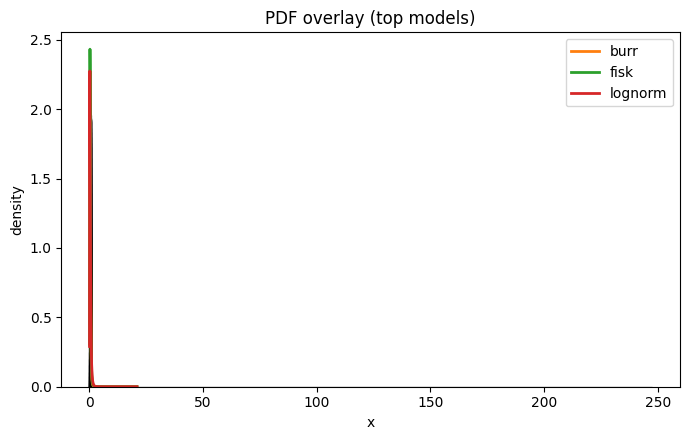

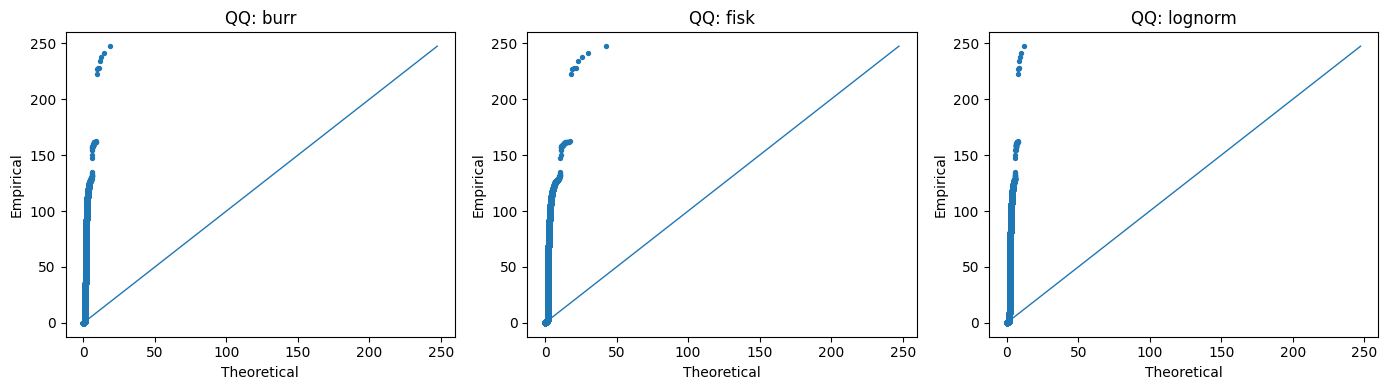

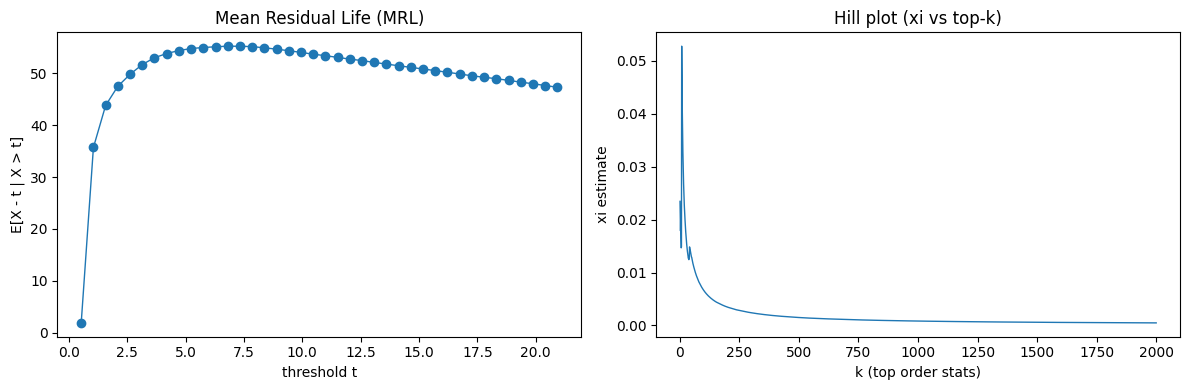


Best (by BIC): burr
KS: D=0.0555, p=0  |  CVM p=2.511e-07
Notes:
- Lognormal/Weibull/Gamma/Log-logistic are common for latencies.
- If Hill plot stabilizes at xi>0 (and MRL grows roughly linearly), tails are heavy; consider POT/GPD.
- If QQ bends up in the right tail vs model → heavier tail than model; bends down → lighter tail.


In [84]:
# Auto-identify a plausible distribution for latency data:
# - Fit multiple families (SciPy)
# - Compare AIC/BIC + KS + Cramér–von Mises
# - Plots for top 3 (PDF overlay + QQ)
# - Heavy-tail diagnostics: MRL + Hill plot
%matplotlib inline

import os, glob, warnings, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ===================== CONFIG =====================
USE_EXISTING_X = False     # set True if you already have x (seconds)
# If False, compute x = application_timestamp - producer_timestamp from Parquet:
ROOT     = "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/consumer"       # <- change me: directory that contains subfolders with parquet files
OUTDIR   = "/Users/soheila/PycharmProjects/PipelineProject/RealTime-Streaming-Pipeline/results/20250826_144753/merge/pot_gpd_app_minus_prod"
APP_COL  = "application_timestamp"
PROD_COL = "producer_timestamp"

# Basic cleaning
DROP_NEGATIVE = True       # drop negative latencies (clock skew, bad rows)
MAX_SAMPLES   = 2_000_000  # downsample if huge (for faster fitting/plotting)

# Candidate continuous distributions (SciPy names)
CANDIDATES = [
    "norm", "lognorm", "expon", "gamma", "weibull_min", "logistic",
    "fisk",        # log-logistic
    "burr",        # Burr XII
    "gengamma",    # generalized gamma
    "weibull_max", # if you suspect a hard cap
    # tails-only models (usually for POT): "pareto"
]
TOP_N_PLOTS = 3
# =================================================

def _to_seconds(series: pd.Series) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce")
    med = np.nanmedian(x)
    if med > 1e14:   # ns
        return x / 1e9
    elif med > 1e11: # ms
        return x / 1e3
    else:            # s
        return x

def _load_latencies_from_parquet(root: str, app_col: str, prod_col: str) -> np.ndarray:
    paths = sorted(glob.glob(os.path.join(root, "**", "*.parquet"), recursive=True))
    if not paths:
        raise SystemExit(f"No parquet files found under: {root}")
    parts = []
    for p in paths:
        try:
            df = pd.read_parquet(p)
            if app_col not in df or prod_col not in df:
                continue
            app_s  = _to_seconds(df[app_col])
            prod_s = _to_seconds(df[prod_col])
            lat = app_s - prod_s
            parts.append(lat.values.astype(float))
        except Exception as e:
            print(f"[WARN] Skip {p}: {e}")
    if not parts:
        raise SystemExit("No usable rows found.")
    x = np.concatenate(parts)
    x = x[np.isfinite(x)]
    if DROP_NEGATIVE:
        x = x[x >= 0]
    if x.size > MAX_SAMPLES:
        rng = np.random.default_rng(0)
        x = rng.choice(x, size=MAX_SAMPLES, replace=False)
    return x

def _fit_one(dist_name: str, x: np.ndarray):
    dist = getattr(stats, dist_name)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        params = dist.fit(x)            # (shape[s], loc, scale)
    # log-likelihood
    ll = np.sum(dist.logpdf(x, *params))
    k = len(params)
    n = len(x)
    aic = 2*k - 2*ll
    bic = k*np.log(n) - 2*ll
    # GOF tests
    ks_D, ks_p = stats.kstest(x, dist_name, args=params)
    try:
        # Cramér–von Mises (more sensitive across the whole support)
        cvm = stats.cramervonmises(x, dist_name, args=params)
        cvm_stat, cvm_p = float(cvm.statistic), float(cvm.pvalue)
    except Exception:
        cvm_stat, cvm_p = math.nan, math.nan
    return dict(
        dist=dist_name, n=n, k=k, ll=ll, AIC=aic, BIC=bic,
        KS_D=ks_D, KS_p=ks_p, CVM=cvm_stat, CVM_p=cvm_p, params=params
    )

def _pdf_xs(x):
    lo, hi = np.nanpercentile(x, 0.5), np.nanpercentile(x, 99.5)
    if hi <= lo: hi = x.max()
    return np.linspace(max(1e-12, lo), hi, 400)

def _qq_plot(x, dist_name, params, ax):
    x = np.sort(x)
    n = len(x)
    probs = (np.arange(1, n+1) - 0.5) / n
    dist = getattr(stats, dist_name)
    theo = dist.ppf(probs, *params)
    ax.scatter(theo, x, s=8)
    mn, mx = np.nanmin([x.min(), theo.min()]), np.nanmax([x.max(), theo.max()])
    ax.plot([mn, mx], [mn, mx], lw=1)
    ax.set_title(f"QQ: {dist_name}")
    ax.set_xlabel("Theoretical"); ax.set_ylabel("Empirical")

def _pdf_overlay(x, fits, ax):
    ax.hist(x, bins="auto", density=True, alpha=0.5, edgecolor="black")
    xs = _pdf_xs(x)
    for name, params in fits:
        dist = getattr(stats, name)
        ax.plot(xs, dist.pdf(xs, *params), lw=2, label=name)
    ax.set_title("PDF overlay (top models)")
    ax.set_xlabel("x"); ax.set_ylabel("density")
    ax.legend()

def _mrl(x, ax, q_start=0.80, q_end=0.995, m=40):
    ts = np.linspace(np.nanquantile(x, q_start), np.nanquantile(x, q_end), m)
    mrl = []
    for t in ts:
        ex = x[x > t] - t
        mrl.append(np.nan if ex.size == 0 else ex.mean())
    ax.plot(ts, mrl, marker='o', lw=1)
    ax.set_title("Mean Residual Life (MRL)")
    ax.set_xlabel("threshold t"); ax.set_ylabel("E[X - t | X > t]")

def _hill_plot(x, ax, max_k=2000):
    # Hill estimator on upper order stats (Pareto tail index alpha = 1/xi)
    x = np.sort(x)
    x = x[~np.isnan(x)]
    x = x[x > 0]
    x = x[-min(len(x), max_k)-1:]      # take largest max_k+1 values
    x = x[::-1]                        # descending
    ks = np.arange(1, len(x))
    H = np.cumsum(np.log(x[:-1]) - np.log(x[1:])) / ks  # Hill xi estimate
    xi = H                                             # xi estimate
    ax.plot(ks, xi, lw=1)
    ax.set_title("Hill plot (xi vs top-k)")
    ax.set_xlabel("k (top order stats)"); ax.set_ylabel("xi estimate")

# --------- load or use existing ----------
if USE_EXISTING_X:
    # Replace with your array of seconds:
    x = np.array([])  # <-- put your data here
    if x.size == 0:
        raise ValueError("Provide your latency array 'x' in seconds.")
else:
    x = _load_latencies_from_parquet(ROOT, APP_COL, PROD_COL)

# Basic sanity cleanup
x = np.asarray(x, float)
x = x[np.isfinite(x)]
if DROP_NEGATIVE:
    x = x[x >= 0]
print(f"Sample size used: {x.size}")

# --------- fit all candidates ----------
rows = []
for name in CANDIDATES:
    try:
        rows.append(_fit_one(name, x))
    except Exception as e:
        print(f"[WARN] {name} fit failed: {e}")

results = pd.DataFrame(rows).sort_values("BIC")
display(results[["dist","n","k","AIC","BIC","KS_D","KS_p","CVM","CVM_p"]].head(10))

# --------- plots for the top 3 by BIC ----------
top = results.nsmallest(TOP_N_PLOTS, "BIC")
fits = [(r["dist"], r["params"]) for _, r in top.iterrows()]

plt.figure(figsize=(7,4.5))
_pdf_overlay(x, fits, plt.gca())
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, min(TOP_N_PLOTS, 3), figsize=(14,4))
if not isinstance(axes, np.ndarray): axes = np.array([axes])
for ax, (_, r) in zip(axes, top.iterrows()):
    _qq_plot(x, r["dist"], r["params"], ax)
plt.tight_layout(); plt.show()

# --------- Heavy-tail diagnostics ----------
fig, axes = plt.subplots(1, 2, figsize=(12,4))
_mrl(x, axes[0])
_hill_plot(x, axes[1])
plt.tight_layout(); plt.show()

# --------- simple reads ---------
best = top.iloc[0]
print("\nBest (by BIC):", best["dist"])
print(f"KS: D={best['KS_D']:.4f}, p={best['KS_p']:.4g}  |  CVM p={best['CVM_p']:.4g}")
print("Notes:")
print("- Lognormal/Weibull/Gamma/Log-logistic are common for latencies.")
print("- If Hill plot stabilizes at xi>0 (and MRL grows roughly linearly), tails are heavy; consider POT/GPD.")
print("- If QQ bends up in the right tail vs model → heavier tail than model; bends down → lighter tail.")


In [87]:
import numpy as np, pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox

# x = latency series in time order (producer→application, seconds)
x = pd.Series(x).dropna().astype(float).values
# simple ACF up to 40 lags
def acf(x, k=40):
    x = (x - x.mean())/x.std()
    return [np.correlate(x[:-h], x[h:])[0]/(len(x)-h) for h in range(1, k+1)]

print("ACF lags 1..10:", np.round(acf(x,10), 3))
print(acorr_ljungbox(x, lags=[10,20], return_df=True))


ACF lags 1..10: [-0.001 -0.001  0.001  0.     0.001 -0.     0.001 -0.     0.001  0.   ]
      lb_stat  lb_pvalue
10   5.997456   0.815477
20  21.653772   0.359590


In [89]:
!pip install ruptures

  Using cached ruptures-1.1.9.tar.gz (308 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... error
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [57 lines of output]
      Compiling src/ruptures/detection/_detection/ekcpd.pyx because it changed.
      Compiling src/ruptures/utils/_utils/convert_path_matrix.pyx because it changed.
      [1/2] Cythonizing src/ruptures/detection/_detection/ekcpd.pyx
      [2/2] Cythonizing src/ruptures/utils/_utils/convert_path_matrix.pyx
      /private/var/folders/2z/bnjkw3qd38b7gqpbhfdmfhpc0000gn/T/pip-build-env-5jx61ldz/overlay/lib/python3.8/site-packages/setuptools_scm/_integration/version_inference.py:51: UserWarning: version of ruptures already set
        warnings.warn(self.message)
      Traceback (most recent call last):
        File "/private/var/folders/2z/bnjkw3qd38b7gqpbhfdmfhpc0000gn/T/pip-build-env-5jx61ldz/overlay/lib/pyt

In [ ]:
import ruptures as rpt
algo = rpt.Binseg(model="l2").fit(x)
bkps = algo.predict(n_bkps=3)
print("Change points (indices):", bkps)
u = np.quantile(x, 0.98)      # high threshold
r = 2.0                        # seconds separating clusters; tune
# t = time stamps (seconds) aligned with x
mask = x > u
t_ex = t[mask]; y_ex = x[mask]
idx = np.argsort(t_ex); t_ex = t_ex[idx]; y_ex = y_ex[idx]
clusters, start = [], 0
for i in range(1, len(y_ex)):
    if t_ex[i] - t_ex[i-1] > r:
        clusters.append(y_ex[start:i]); start = i
clusters.append(y_ex[start:])
theta = len(clusters)/len(y_ex)
print(f"Extremal index θ ≈ {theta:.3f} (1=indep, <1=clustering)")
